# LambdaLLG 2D STT skyrmion motion

This notebook uses the 2D Zhang-Li spin-transfer torque to drive a zero-field Neel skyrmion on a square lattice.

We use the phenomenological torque

$$
\left.\partial_t \mathbf{m}\right|_{\mathrm{STT}} = -(\mathbf{u} \cdot \nabla)\mathbf{m} + \beta \, \mathbf{m} \times \left[(\mathbf{u} \cdot \nabla)\mathbf{m}\right],
$$

with $\mathbf{u} = (u_x, u_y)$ in lattice-spacing units $a = 1$.


In [1]:
using Pkg; Pkg.activate("../")


  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
using LambdaLLG
using LinearAlgebra
import PyPlot as plt


[ Info: Precompiling LambdaLLG [e49eaffb-1ff4-4058-b8bd-8b5ecf266929] (cache misses: include_dependency fsize change (2), mismatched flags (10))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Helpers

The line plots follow the package color convention: blue and green for the tracked $x$ and $y$ positions, and red for the topological-charge trace. Texture maps use `pcolormesh` on $m_z$.


In [3]:
function skyrmion_seed(Nx, Ny; radius=9.0, width=2.5, chirality=1.0, polarity=-1.0)
    s0 = zeros(3, Nx, Ny)
    x0 = (Nx + 1) / 2
    y0 = (Ny + 1) / 2

    for j in 1:Ny, i in 1:Nx
        dx = i - x0
        dy = j - y0
        r = hypot(dx, dy)
        mz = polarity * tanh((radius - r) / width)
        mxy = sqrt(max(0.0, 1.0 - mz^2))

        if r < 1e-12
            s0[:, i, j] .= (0.0, 0.0, polarity)
        else
            s0[:, i, j] .= (chirality * mxy * dx / r, chirality * mxy * dy / r, mz)
        end
    end

    normalize_spins!(s0)
    return s0
end

function core_center(spins)
    weights = max.(0.0, 1 .- spins[3, :, :])
    total = sum(weights)
    cx = 0.0
    cy = 0.0

    for j in axes(spins, 3), i in axes(spins, 2)
        w = weights[i, j]
        cx += w * i
        cy += w * j
    end

    return (cx / total, cy / total)
end

function center_series(sol, Nx, Ny)
    cx = zeros(length(sol.t))
    cy = zeros(length(sol.t))
    for n in eachindex(sol.t)
        center = core_center(reshape(sol.u[n], 3, Nx, Ny))
        cx[n] = center[1]
        cy[n] = center[2]
    end
    return cx, cy
end

function topological_charge(spins)
    q = 0.0
    for j in 2:size(spins, 3)-1, i in 2:size(spins, 2)-1
        sx = 0.5 .* (spins[:, i + 1, j] .- spins[:, i - 1, j])
        sy = 0.5 .* (spins[:, i, j + 1] .- spins[:, i, j - 1])
        q += dot(spins[:, i, j], cross(sx, sy))
    end
    return q / (4pi)
end

charge_series(sol, Nx, Ny) = [topological_charge(reshape(u, 3, Nx, Ny)) for u in sol.u]

function plot_texture!(ax, spins; stride=4, title="")
    mz = spins[3, :, :]
    Nx, Ny = size(spins, 2), size(spins, 3)
    xs = 1:stride:Nx
    ys = 1:stride:Ny
    X = [i for j in ys, i in xs]
    Y = [j for j in ys, i in xs]
    U = [spins[1, i, j] for j in ys, i in xs]
    V = [spins[2, i, j] for j in ys, i in xs]

    im = ax.pcolormesh(mz', cmap="RdBu_r", vmin=-1, vmax=1, shading="nearest")
    ax.quiver(X, Y, U, V, color="lightgreen", pivot="mid", scale=20, linewidth=1.5)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    return im
end


plot_texture! (generic function with 1 method)

## 1. Relax a zero-field Neel skyrmion

We use interfacial DMI,

$$
\mathbf{D}_x = (0, D, 0), \qquad \mathbf{D}_y = (-D, 0, 0),
$$

which favors a Neel skyrmion on the square lattice. The external field is set to zero throughout.


In [4]:
Nx = 81
Ny = 81
J = 1.0
K = (0.0, 0.0, 0.15)
D = ((0.0, 0.2, 0.0), (-0.2, 0.0, 0.0))
alpha = 0.25
u_stt = (0.10, 0.0)
beta_stt = 0.25

tspan_relax = (0.0, 80.0)
tspan_drive = (0.0, 80.0)

s0 = skyrmion_seed(Nx, Ny; radius=9.0, width=2.5, chirality=1.0, polarity=-1.0)
p = LLGParams2D(Nx, Ny, J, K, (0.0, 0.0, 0.0), alpha; D=D, u_stt=u_stt, beta_stt=beta_stt)

sol_relax = evolve2D(copy(s0), tspan_relax, p; reltol=1e-6, abstol=1e-6)
s_relaxed = reshape(copy(sol_relax.u[end]), 3, Nx, Ny)

display((
    seed_center = core_center(s0),
    relaxed_center = core_center(s_relaxed),
    Q_seed = topological_charge(s0),
    Q_relaxed = topological_charge(s_relaxed),
))


(seed_center = (40.99999999999978, 40.99999999999988), relaxed_center = (41.00000000000014, 41.00000000000005), Q_seed = -0.9718314116634466, Q_relaxed = -0.9362987323028126)

## 2. Compare the zero-current control against STT-driven motion

The control run uses the same relaxed skyrmion and the same material parameters, but with `stt=false`. The driven run differs only by enabling the 2D STT term.


In [5]:
sol_control = evolve2D(copy(s_relaxed), tspan_drive, p; reltol=1e-6, abstol=1e-6, stt=false)
sol_drive = evolve2D(copy(s_relaxed), tspan_drive, p; reltol=1e-6, abstol=1e-6, stt=true)

cx_control, cy_control = center_series(sol_control, Nx, Ny)
cx_drive, cy_drive = center_series(sol_drive, Nx, Ny)
q_control = charge_series(sol_control, Nx, Ny)
q_drive = charge_series(sol_drive, Nx, Ny)

s_drive = reshape(copy(sol_drive.u[end]), 3, Nx, Ny)

display((
    control_delta = (cx_control[end] - cx_control[1], cy_control[end] - cy_control[1]),
    drive_delta = (cx_drive[end] - cx_drive[1], cy_drive[end] - cy_drive[1]),
    Q_control_final = q_control[end],
    Q_drive_final = q_drive[end],
))


(control_delta = (7.815970093361102e-14, -9.237055564881302e-14), drive_delta = (7.591583346510717, -0.046711151549068575), Q_control_final = -0.9353067371288913, Q_drive_final = -0.9358524588800089)

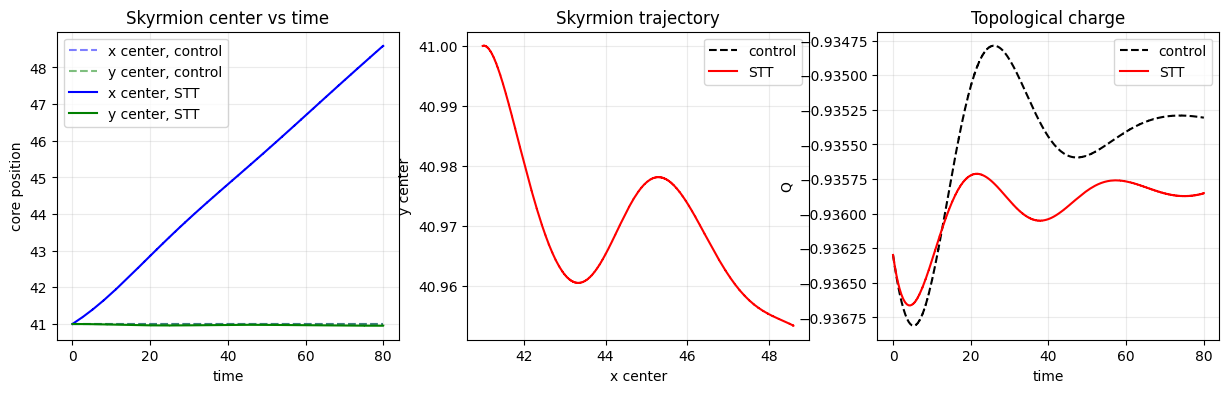

PyObject <matplotlib.legend.Legend object at 0x00000228E4B70610>

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[1].plot(sol_control.t, cx_control, color="blue", linestyle="--", alpha=0.5, label="x center, control")
ax[1].plot(sol_control.t, cy_control, color="green", linestyle="--", alpha=0.5, label="y center, control")
ax[1].plot(sol_drive.t, cx_drive, color="blue", label="x center, STT")
ax[1].plot(sol_drive.t, cy_drive, color="green", label="y center, STT")
ax[1].set_xlabel("time")
ax[1].set_ylabel("core position")
ax[1].set_title("Skyrmion center vs time")
ax[1].grid(true, alpha=0.25)
ax[1].legend(loc="best")

ax[2].plot(cx_control, cy_control, color="black", linestyle="--", label="control")
ax[2].plot(cx_drive, cy_drive, color="red", label="STT")
ax[2].set_xlabel("x center")
ax[2].set_ylabel("y center")
ax[2].set_title("Skyrmion trajectory")
ax[2].grid(true, alpha=0.25)
ax[2].legend(loc="best")

ax[3].plot(sol_control.t, q_control, color="black", linestyle="--", label="control")
ax[3].plot(sol_drive.t, q_drive, color="red", label="STT")
ax[3].set_xlabel("time")
ax[3].set_ylabel("Q")
ax[3].set_title("Topological charge")
ax[3].grid(true, alpha=0.25)
ax[3].legend(loc="best")


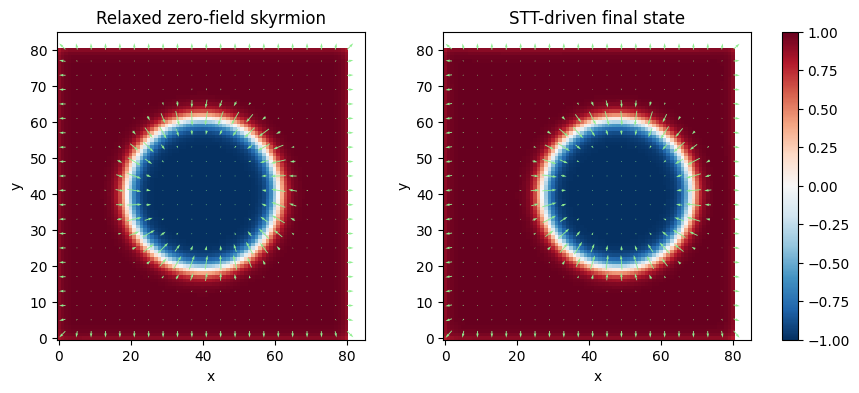

PyObject <matplotlib.colorbar.Colorbar object at 0x00000228E4A71450>

In [7]:
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 4))
plot_texture!(ax2[1], s_relaxed; title="Relaxed zero-field skyrmion")
im = plot_texture!(ax2[2], s_drive; title="STT-driven final state")
fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)


## Notes and references

For this tuned parameter set, the control skyrmion stays centered while the STT-driven skyrmion translates predominantly along $+x$ with only a very small transverse drift, all at zero external field. The topological charge remains close to its relaxed value during the driven motion, so this serves as a useful qualitative sanity check for the 2D STT implementation.

References:

- Shufeng Zhang and Zhidong Li, *Physical Review Letters* **93**, 127204 (2004), <https://doi.org/10.1103/PhysRevLett.93.127204>
- Andre Thiaville, Yuriy Nakatani, Jurgen Miltat, and Nicolas Vernier, *Europhysics Letters* **69**, 990 (2005), <https://doi.org/10.1209/epl/i2004-10452-6>
- Junichi Iwasaki, Masahito Mochizuki, and Naoto Nagaosa, *Nature Communications* **4**, 1463 (2013), <https://doi.org/10.1038/ncomms2442>
